<a href="https://colab.research.google.com/github/vinayakkarigar/hands-on-ML/blob/main/fundamentals/1.1-vectors-and-graphics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Drawing with 2D Vectors
- Creating and manipulating 2D drawings as a collection of vectors
- Thinking of 2D vectors as arrows, locations and ordered pair of coordinates
- Using vector arithmetic to transform shapes in the plane
- Using trignometry to measure distance and angles in the plane













# Importing essential libraries and utilities

In [63]:
# Importing essential libraries and utilities
!git clone https://github.com/orlandpm/Math-for-Programmers.git
import sys
sys.path.append('/content/Math-for-Programmers')
!cp -r /content/Math-for-Programmers/Chapter\ 02/* /content
!cp -r /content/Math-for-Programmers/Chapter\ 03/* /content
from vector_drawing import *
from draw3d import *
from math import pi


fatal: destination path 'Math-for-Programmers' already exists and is not an empty directory.


# 2D Vectors

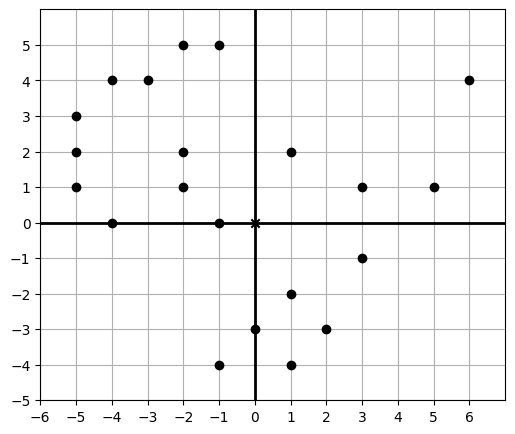

In [32]:
# Draw Dino as dots
dino_vectors = [(6,4), (3,1), (1,2), (-1,5), (-2,5), (-3,4), (-4,4),
    (-5,3), (-5,2), (-2,2), (-5,1), (-4,0), (-2,1), (-1,0), (0,-3),
    (-1,-4), (1,-4), (2,-3), (1,-2), (3,-1), (5,1)
]

draw(Points(*dino_vectors))

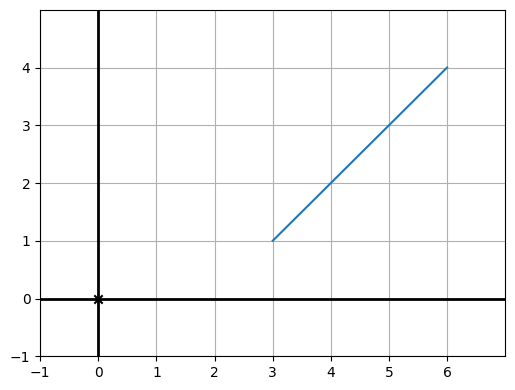

In [35]:
# Draw a line segment
draw(Segment((6,4), (3,1)))

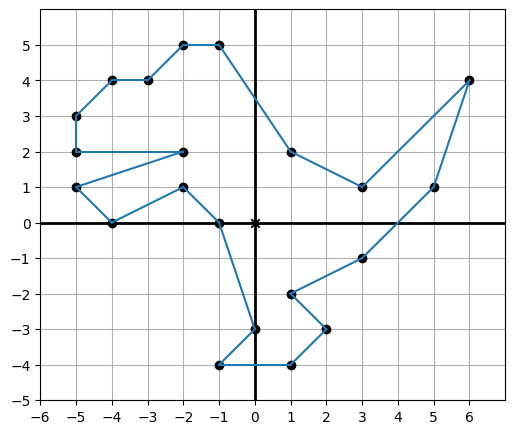

In [36]:
# Draw complete Dino
draw(
   Points(*dino_vectors),
   Polygon(*dino_vectors)
)

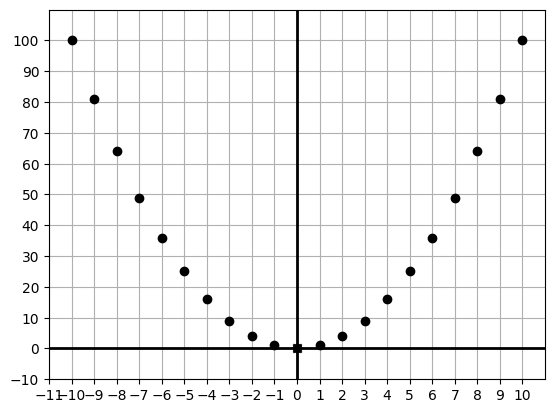

In [38]:
# Draw the vectors (x,x**2) for x in the range from x = −10 to x = 11) as points (dots) using the draw function. What is the result?

draw(
    Points(*[(x,x**2) for x in range(-10,11)]),
    grid = (1,10),
    nice_aspect_ratio=False)

# Plane vector arithmetic

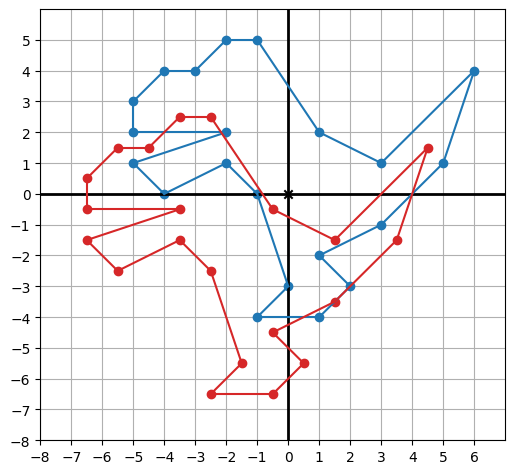

In [41]:
# Define add operator for the vector
def add(v1,v2):
   return (v1[0] + v2[0], v1[1] + v2[1])

# Shift Dino
dino_vectors2 = [add((-1.5,-2.5), v) for v in dino_vectors]

draw(
   Points(*dino_vectors, color=blue),
   Polygon(*dino_vectors, color=blue),
   Points(*dino_vectors2, color=red),
   Polygon(*dino_vectors2, color=red)
)

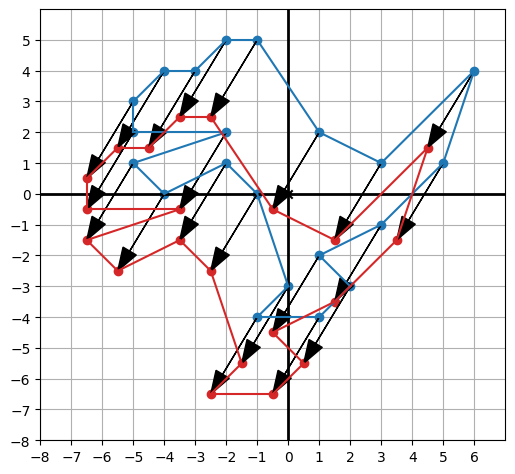

In [43]:
arrows = [Arrow(tip,tail,color=black) for (tip,tail) in
         zip(dino_vectors2, dino_vectors)]
draw(
    Points(*dino_vectors, color=blue),
    Polygon(*dino_vectors, color=blue),
    Points(*dino_vectors2, color=red),
    Polygon(*dino_vectors2, color=red),
    *arrows
)

In [56]:
# Vector components and lengths

# Define length of a vector
from math import sqrt
def length(v):
   return sqrt(v[0]**2 + v[1]**2)

def add(*vectors):
  return (sum([v[0] for v in vectors]),sum([v[1] for v in vectors]))

def subtract(v1,v2):
   return (v1[0] -  v2[0], v1[1] - v2[1])

def distance(v1,v2):
   return length(subtract(v1,v2))

def perimeter(vectors):
   distances = [distance(vectors[i], vectors[(i+1)%len(vectors)])
                for i in range(0,len(vectors))]
   return sum(distances)




In [46]:
# Translation
def translate(translation, vectors):
    return [add(translation, v) for v in vectors]

translate((1,1), [(0,0), (0,1,), (-3,-3)])

[(1, 1), (1, 2), (-2, -2)]

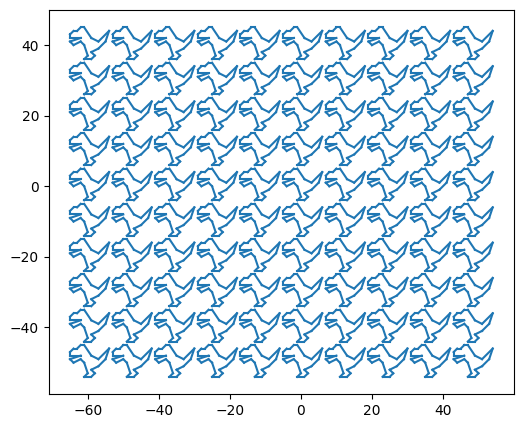

In [48]:
# 100 dinos
def hundred_dinos():
   translations = [(12*x,10*y)
                   for x in range(-5,5)
                   for y in range(-5,5)]
   dinos = [Polygon(*translate(t, dino_vectors),color=blue)
               for t in translations]
   draw(*dinos, grid=None, axes=None, origin=None)

hundred_dinos()

In [50]:
max(dino_vectors, key=length)

(6, 4)

In [52]:
# definition of scale function
def scale(scalar,v):
   return (scalar * v[0], scalar * v[1])


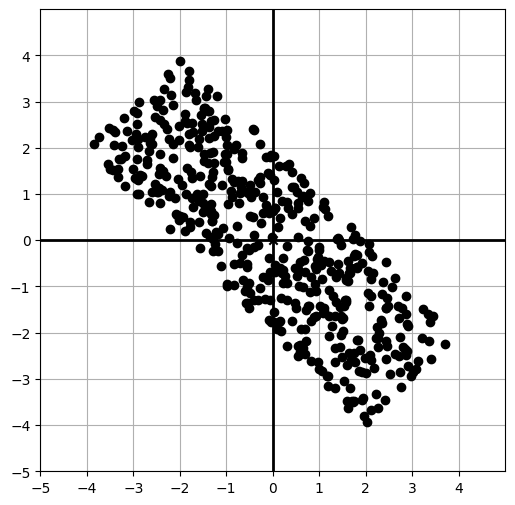

In [53]:
# Suppose z = (−1, 1) and v = (1, 1), and suppose r and s are real numbers. Specifically, let’s assume −3 < r < 3 and −1 < s < 1. Where are the possible points on the plane where the vector r · u + s · v could end up?

from random import uniform
u = (-1,1)
v = (1,1)
def random_r():
   return uniform(-3,3)
def random_s():
   return uniform(-1,1)

possibilities = [add(scale(random_r(), u), scale(random_s(), v))
                for i in range(0,500)]
draw(
   Points(*possibilities)
)

# Polar Coordinates


In [60]:
from math import sin, cos, atan2
def to_cartesian(polar_vector):
   length, angle = polar_vector[0], polar_vector[1]
   return (length*cos(angle), length*sin(angle))

def to_polar(vector):
   x, y = vector[0], vector[1]
   angle = atan2(y,x)
   return (length(vector), angle)

def rotate(angle, vectors):
    polars = [to_polar(v) for v in vectors]
    return [to_cartesian((l, a+angle)) for l,a in polars]


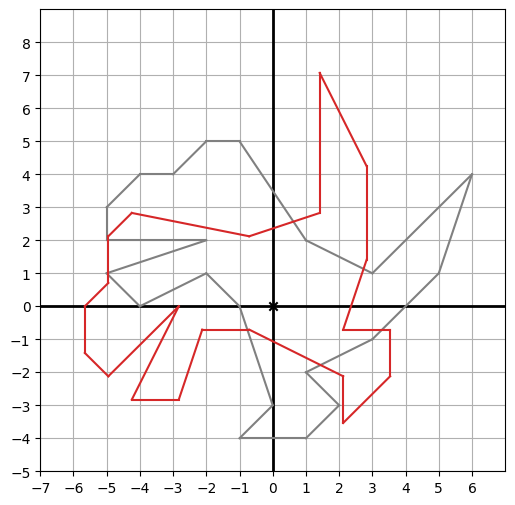

In [59]:
rotation_angle = pi/4
dino_polar = [to_polar(v) for v in dino_vectors]
dino_rotated_polar = [(l,angle + rotation_angle) for l,angle in dino_polar]
dino_rotated = [to_cartesian(p) for p in dino_rotated_polar]
draw(
   Polygon(*dino_vectors, color=gray),
   Polygon(*dino_rotated, color=red)
)

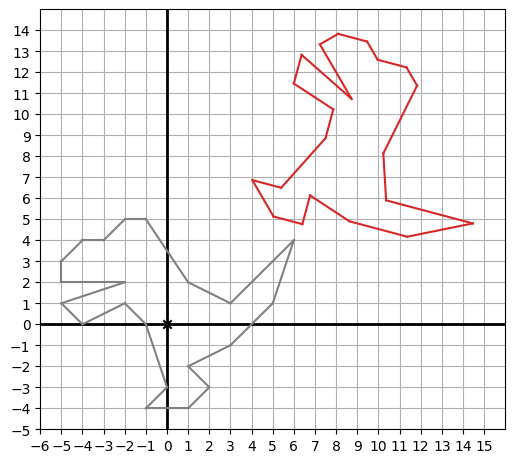

In [61]:
new_dino = translate((8,8), rotate(5 * pi/3, dino_vectors))
draw(
   Polygon(*dino_vectors, color=gray),
   Polygon(*new_dino, color=red)
)

# Ascending to the 3D world

## 3D Drawing with python

###### TODO - Arrow3D not working check the version for matplotlib in which it works. Also check the versions of libs available by default in Collabs



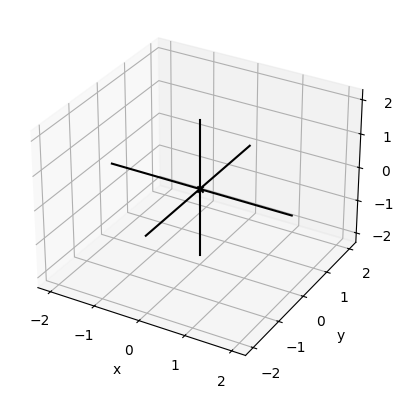

In [65]:
# Empty 3D Grid
draw3d()


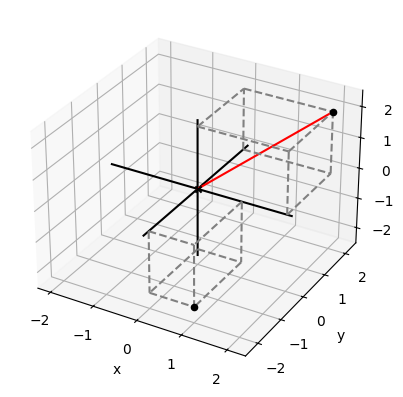

In [77]:
# Points Arrows and segments in 3D
draw3d(
   Points3D((2,2,2),(1,-2,-2)),
   Segment3D((0,0,0), (2,2,2), color='red'),
   Box3D(2,2,2),
   Box3D(1,-2,-2)
)


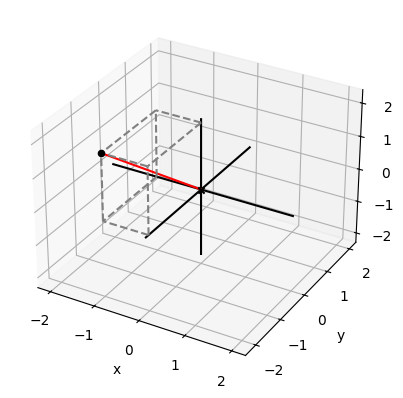

In [84]:
# Draw the 3D arrow and point representing the coordinates (−1, −2, 2) as well as the dashed box that makes the arrow look 3D. Do this drawing by hand for practice, but from now on, we’ll use Python to draw for us

draw3d(
    Points3D((-1,-2,2)),
    Segment3D((0,0,0), (-1,-2,2), color='red'),
    Box3D(-1,-2,2)
)

In [ ]:
 # There are exactly eight 3D vectors whose coordinates are all either +1 or −1. For instance, (1, −1, 1) is one of these. Plot all of these eight vectors as points. \
 # Then figure out how to connect them with line segments using Segment3D objects to form the outline of a cube.



